# Hyperparameters experimenting stable-baselines - Experiments on one agent using PettingZoo

In this notebook, different values of the gamma and learning_rate hyperparameters are being examined during the learning process.

In [2]:
from environment import TrafficEnvironment
from keychain import Keychain as kc
import os
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3 import PPO
import supersuit as ss
from Sumo_controller import Sumo
import matplotlib.pyplot as plt
import numpy as np

from utilities import confirm_env_variable
from utilities import get_params
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


In [4]:
Sumo_sim=Sumo(params)
Sumo_sim.Sumo_start()

In [5]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS])

[SUCCESS] Generated & saved 12 paths to: paths.csv
[SUCCESS] Environment initiated!
[INFO] Free-flow times:  {(0, 0): [79.08057682894723, 53.949843117513176, 2080.7983107291316], (0, 1): [538.7942356992961, 35.0020862628709, 2381.8551334292406], (1, 0): [15.82545457780203, 442.1212966299939, 584.532583096493], (1, 1): [115.71839621377714, 18.282988875895942, 4307.901388510148]}
[SUCCESS] Free flow times calculated!
[SUCCESS]: The vehicle will travel from origin  [0]  to destination. [0]  This path has free flow travel time:  [79.08057682894723, 53.949843117513176, 2080.7983107291316]


In [6]:
env.reset()
env.reward_table = []

In [7]:
env = ss.pettingzoo_env_to_vec_env_v1(env)
env = ss.concat_vec_envs_v1(env, 1, num_cpus=2, base_class="stable_baselines3")

In [8]:
# Define the parameter ranges you want to test
gamma_range = np.linspace(0.85, 0.975, 10) 

Reward table is:  [-2652.6666666666665, -98.16666666666667, -98.16666666666667, -98.16666666666667, -98.16666666666667, -2652.6666666666665, -2652.6666666666665, -65.36666666666666, -65.36666666666666, -65.36666666666666, -2652.6666666666665, -65.36666666666666, -65.36666666666666, -2652.6666666666665, -65.36666666666666, -2652.6666666666665, -65.36666666666666, -2652.6666666666665, -65.36666666666666, -65.36666666666666]
Actions are:  [2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1]


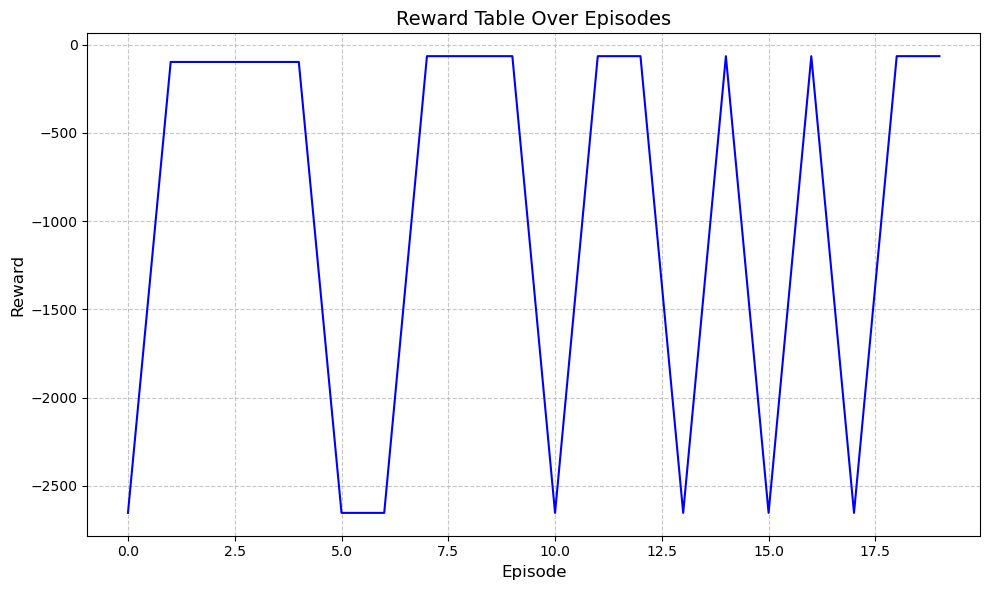

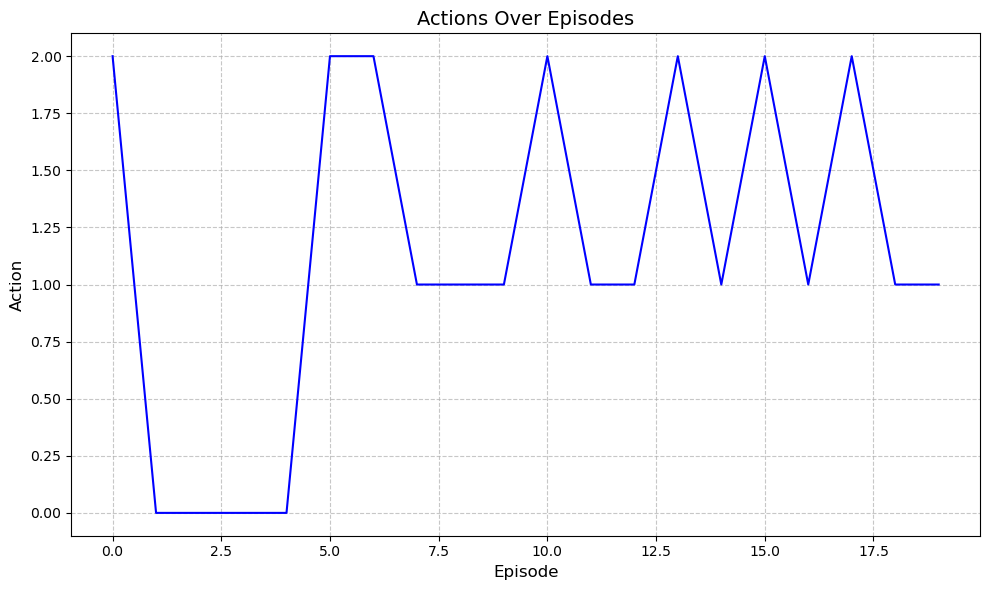

Reward table is:  [-98.16666666666667, -65.36666666666666, -2652.6666666666665, -65.36666666666666, -65.36666666666666, -2652.6666666666665, -2652.6666666666665, -65.36666666666666, -65.36666666666666, -98.16666666666667, -98.16666666666667, -65.36666666666666, -65.36666666666666, -65.36666666666666, -65.36666666666666, -2652.6666666666665, -2652.6666666666665, -98.16666666666667, -65.36666666666666, -65.36666666666666]
Actions are:  [2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 0, 1, 1]


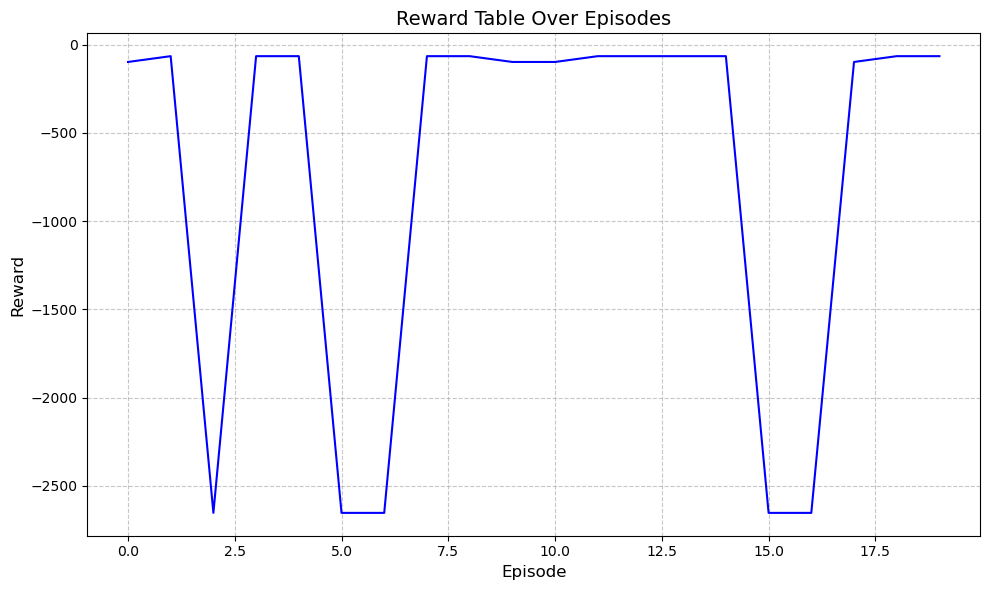

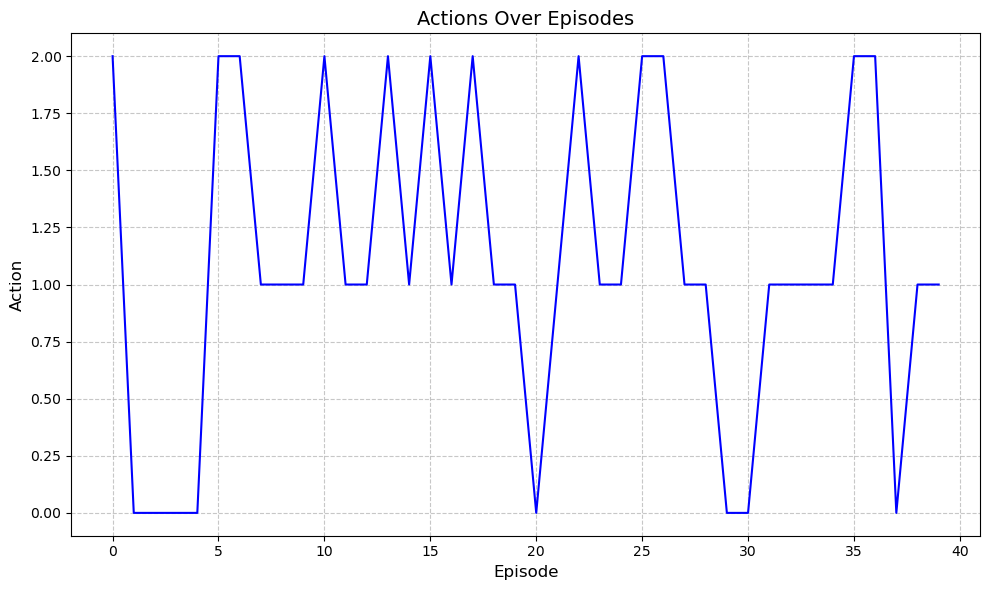

Reward table is:  [-65.36666666666666, -2652.6666666666665, -98.16666666666667, -98.16666666666667, -98.16666666666667, -65.36666666666666, -98.16666666666667, -65.36666666666666, -65.36666666666666, -65.36666666666666, -98.16666666666667, -65.36666666666666, -2652.6666666666665, -98.16666666666667, -2652.6666666666665, -98.16666666666667, -98.16666666666667, -2652.6666666666665, -65.36666666666666, -98.16666666666667]
Actions are:  [2, 0, 0, 0, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 2, 2, 0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 2, 0, 2, 0, 0, 2, 1, 0]


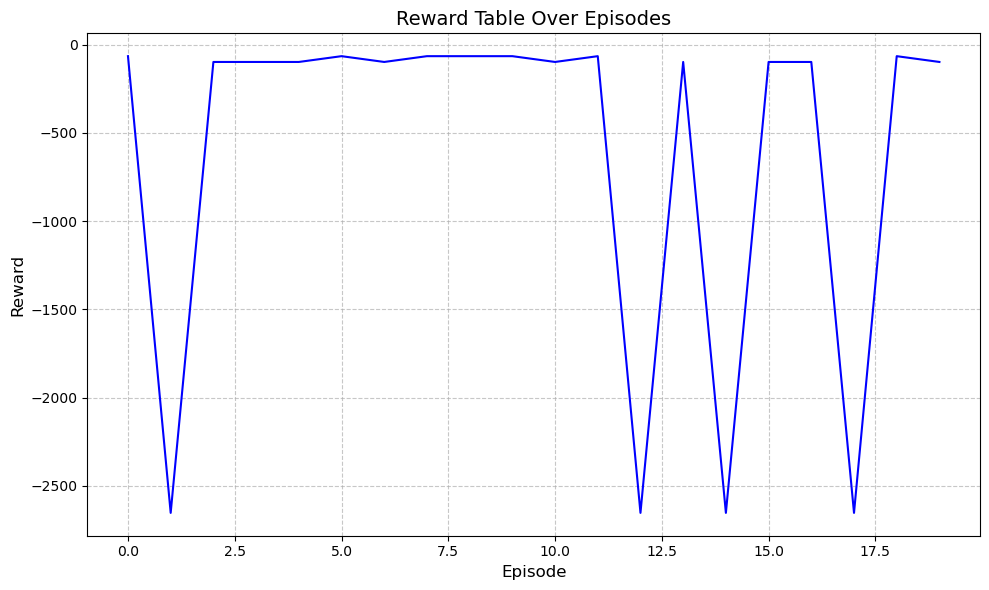

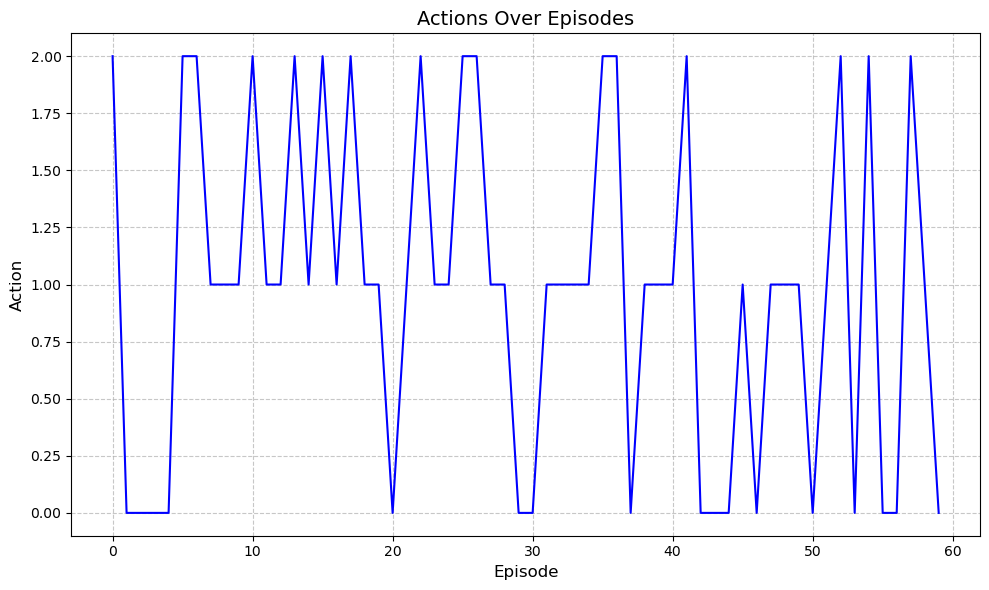

KeyboardInterrupt: 

In [9]:
for gamma in gamma_range:
    # Define the parameters for the model
    tuned_params = {
        "gamma": gamma,
        "learning_rate": 1e-3,
    }

    # Create the model
    model = PPO("MlpPolicy", env, verbose=0, n_steps=10, batch_size=10, **tuned_params)

    # Train the model
    model.learn(total_timesteps=20)  # Example: 20 total timesteps

    env.close()
    env.reward_table = []